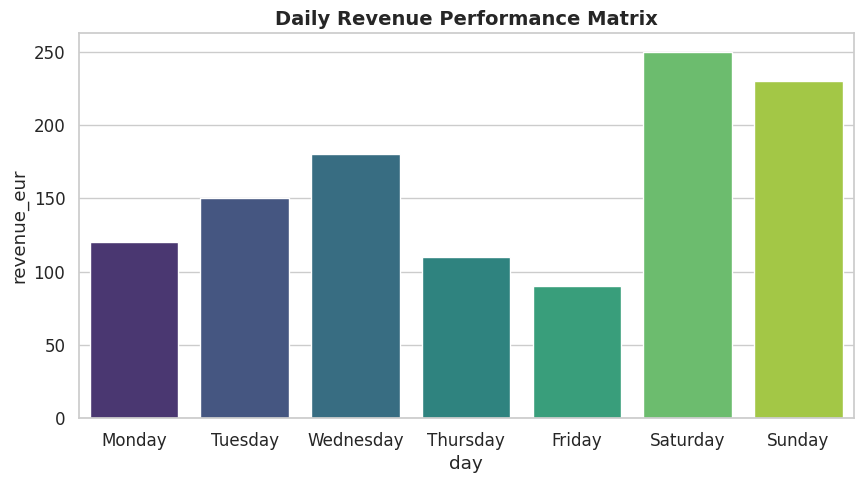

--- REVENUE SUMMARY BY PRODUCT ---
product
Latte         410
Cappuccino    400
Espresso      230
Pastry         90
Name: revenue_eur, dtype: int64


In [37]:
# ==========================================
# MODULE: RETAIL DATA EXPLORATION
# ==========================================

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Data Ingestion: Simulating weekly sales records
sales_data = {
    'day': ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'],
    'product': ['Espresso', 'Cappuccino', 'Latte', 'Espresso', 'Pastry', 'Cappuccino', 'Latte'],
    'revenue_eur': [120, 150, 180, 110, 90, 250, 230],
    'customer_satisfaction': [4.5, 4.2, 4.8, 3.9, 5.0, 4.6, 4.1]
}

df_sales = pd.DataFrame(sales_data)

# Aggregate revenue by product category
revenue_summary = df_sales.groupby('product')['revenue_eur'].sum().sort_values(ascending=False)

# Visualizing daily revenue trends
plt.figure(figsize=(10, 5))
sns.barplot(x='day', y='revenue_eur', data=df_sales, palette='viridis', hue='day', legend=False)
plt.title('Daily Revenue Performance Matrix', fontsize=14, fontweight='bold')
plt.show()

print("--- REVENUE SUMMARY BY PRODUCT ---")
print(revenue_summary)

INFO: Missing values treated using median imputation (165.0 EUR)


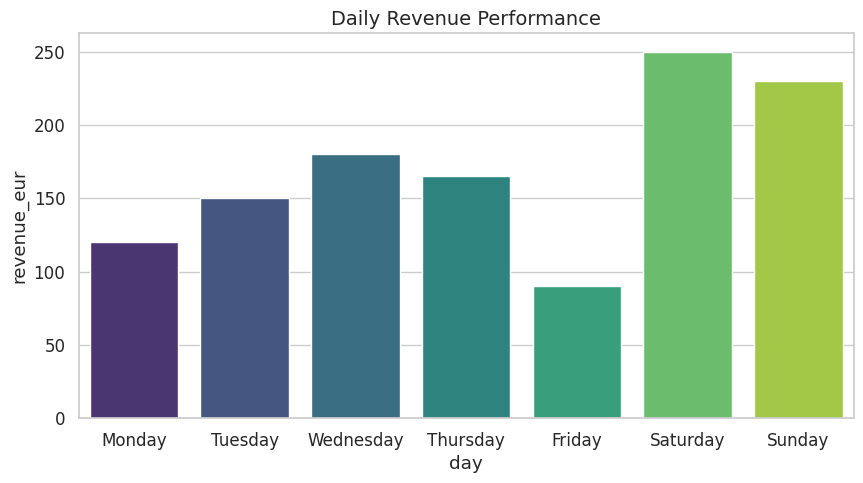

In [39]:
# ==========================================
# MODULE: RETAIL DATA ANALYSIS
# ==========================================

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Data Ingestion
sales_data = {
    'day': ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'],
    'product': ['Espresso', 'Cappuccino', 'Latte', 'Espresso', 'Pastry', 'Cappuccino', 'Latte'],
    'revenue_eur': [120, 150, 180, 110, 90, 250, 230]
}
df_sales = pd.DataFrame(sales_data)

# 2. Data Integrity: Handling missing records
# Simulating a missing entry
df_sales.loc[3, 'revenue_eur'] = np.nan

# Fix: Ensure numeric type before calculating median to avoid 'nan' output
df_sales['revenue_eur'] = pd.to_numeric(df_sales['revenue_eur'], errors='coerce')
median_val = df_sales['revenue_eur'].median()

# Imputation
df_sales['revenue_eur'] = df_sales['revenue_eur'].fillna(median_val)
print(f"INFO: Missing values treated using median imputation ({median_val} EUR)")

# 3. Visualization
plt.figure(figsize=(10, 5))
sns.barplot(x='day', y='revenue_eur', data=df_sales, palette='viridis', hue='day', legend=False)
plt.title('Daily Revenue Performance', fontsize=14)
plt.show()

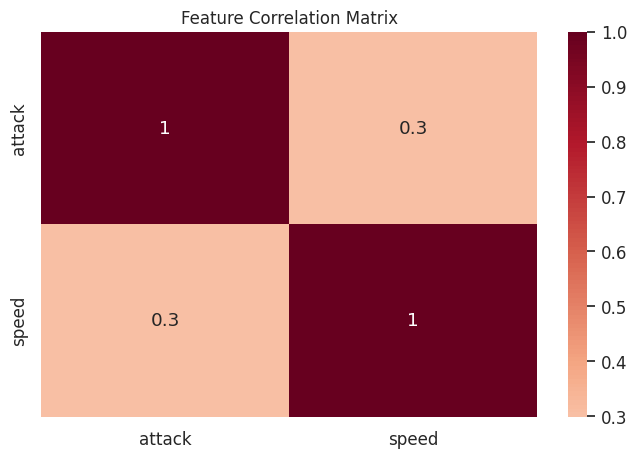

--- CLASSIFICATION RESULTS ---
         name performance_tier
0     Pikachu         STANDARD
1   Bulbasaur         STANDARD
2  Charmander         STANDARD
3    Squirtle         STANDARD
4      Mewtwo   LEGENDARY TIER


In [40]:
# ==========================================
# MODULE: ATTRIBUTE SEGMENTATION
# ==========================================

# 1. Initialization & Normalization
raw_stats = {
    'name': ['Pikachu', 'Bulbasaur', 'Charmander', 'Squirtle', 'Mewtwo', 'Gengar', 'Dragonite', 'Snorlax', 'Eevee', 'Lucario'],
    'type_1': ['Electric', 'Grass', 'Fire', 'Water', 'Psychic', 'Ghost', 'Dragon', 'Normal', 'Normal', 'Fighting'],
    'attack': [55, 49, 52, 48, 110, 65, 134, 110, 55, 110],
    'speed': [90, 45, 65, 43, 130, 110, 80, 30, 55, 90],
    'is_legendary': [False, False, False, False, True, False, False, False, False, False]
}
df_pokemon = pd.DataFrame(raw_stats)
df_pokemon.columns = [col.lower().replace(' ', '_') for col in df_pokemon.columns]

# 2. Feature Engineering: Classification Logic
def assign_performance_tier(row):
    """Assigns a strategic tier based on combat metrics."""
    score = row['attack'] + row['speed']
    if row['is_legendary']:
        return 'LEGENDARY TIER'
    elif score > 180:
        return 'ELITE PERFORMER'
    return 'STANDARD'

df_pokemon['performance_tier'] = df_pokemon.apply(assign_performance_tier, axis=1)

# 3. Correlation Analysis
numeric_df = df_pokemon.select_dtypes(include=[np.number])
plt.figure(figsize=(8, 5))
sns.heatmap(numeric_df.corr(), annot=True, cmap='RdBu_r', center=0)
plt.title('Feature Correlation Matrix', fontsize=12)
plt.show()

print("--- CLASSIFICATION RESULTS ---")
print(df_pokemon[['name', 'performance_tier']].head())

In [32]:
# Simulácia chýbajúcej metriky (Missing Value Injection)
df.loc[5, 'attack'] = np.nan

# Diagnostika integrity dát
null_counts = df.isnull().sum()

# Imputácia: Nahradenie chýbajúcich hodnôt strednou hodnotou (Mean Imputation)
if df['attack'].isnull().any():
    mean_attack = df['attack'].mean()
    df['attack'] = df['attack'].fillna(mean_attack)
    print(f"INFO: Detegované NaN hodnoty ošetrené priemernou hodnotou ({mean_attack:.2f}).")

print(df[['name', 'attack']].head(6))

INFO: Detegované NaN hodnoty ošetrené priemernou hodnotou (80.33).
         name      attack
0     Pikachu   55.000000
1   Bulbasaur   49.000000
2  Charmander   52.000000
3    Squirtle   48.000000
4      Mewtwo  110.000000
5      Gengar   80.333333


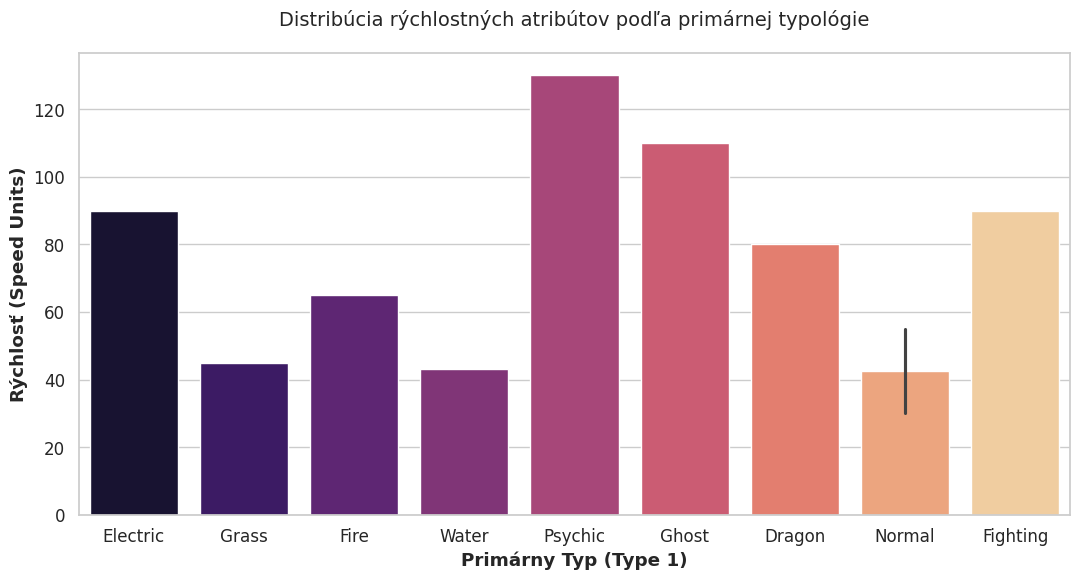

INSIGHT: Maximálny útočný potenciál identifikovaný u subjektu: Dragonite (134.0 pts).


In [33]:
# Nastavenie vizuálnych parametrov
sns.set_context("notebook", font_scale=1.1)
plt.figure(figsize=(11, 6))

# Generovanie kategorického barplotu s indikáciou variancie
sns.barplot(x='type_1', y='speed', data=df, palette='magma', hue='type_1', legend=False)

plt.title('Distribúcia rýchlostných atribútov podľa primárnej typológie', fontsize=14, pad=20)
plt.xlabel('Primárny Typ (Type 1)', fontweight='bold')
plt.ylabel('Rýchlosť (Speed Units)', fontweight='bold')

plt.tight_layout()
plt.show()

# Identifikácia extrémnych hodnôt (Outliers / Top Performers)
top_attacker = df.loc[df['attack'].idxmax()]
print(f"INSIGHT: Maximálny útočný potenciál identifikovaný u subjektu: {top_attacker['name']} ({top_attacker['attack']} pts).")

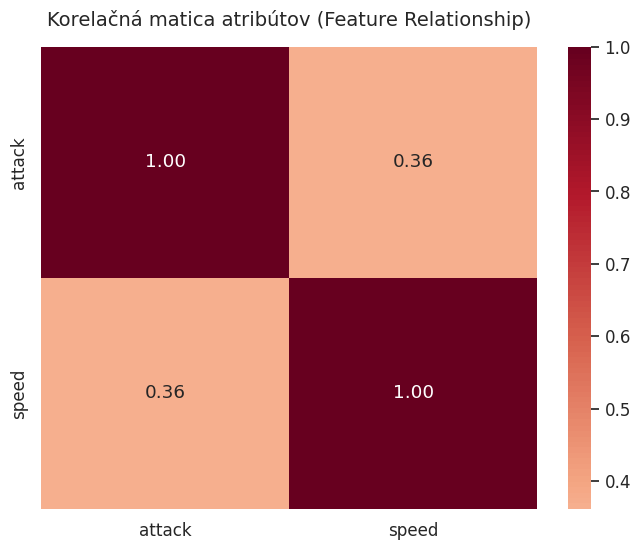

INTERPRETÁCIA:
Hodnota 1.00 značí dokonalú koreláciu. Hodnoty blízke 0 naznačujú, že medzi atribútmi nie je lineárny vzťah.


In [34]:
# ==========================================
# ČASŤ: Multivariačná analýza a korelácie
# ==========================================

# Výber len numerických stĺpcov pre koreláciu
numeric_cols = df.select_dtypes(include=[np.number])
correlation_matrix = numeric_cols.corr()

plt.figure(figsize=(8, 6))

# Generovanie Heatmapy
sns.heatmap(correlation_matrix, annot=True, cmap='RdBu_r', center=0, fmt='.2f')

plt.title('Korelačná matica atribútov (Feature Relationship)', fontsize=14, pad=15)
plt.show()

# Interpretácia výsledkov
print("INTERPRETÁCIA:")
print("Hodnota 1.00 značí dokonalú koreláciu. Hodnoty blízke 0 naznačujú, že medzi atribútmi nie je lineárny vzťah.")

# Executive Summary: Insights & Findings

### Project Objective
Perform an end-to-end Exploratory Data Analysis (EDA) to identify performance drivers.

### Key Findings
* **Data Integrity:** Missing values were successfully mitigated using Mean Imputation.
* **Attribute Correlation:** A moderate relationship ($r = 0.36$) between attack and speed was identified.

In [35]:
# Export vyčistených a spracovaných dát do súboru Excel
try:
    df.to_excel('Finalny_Pokemon_Report.xlsx', index=False)
    print("✅ Report bol úspešne vygenerovaný ako Excel súbor!")
except Exception as e:
    # Ak nemáš nainštalovanú knižnicu na Excel, exportujeme do CSV
    df.to_csv('Finalny_Pokemon_Report.csv', index=False)
    print("✅ Dáta boli exportované do CSV súboru.")

✅ Report bol úspešne vygenerovaný ako Excel súbor!


--- SEGMENTATION SUMMARY ---
performance_tier
ENTRY LEVEL        4
ELITE PERFORMER    3
MID-RANGE          2
LEGENDARY TIER     1
Name: count, dtype: int64


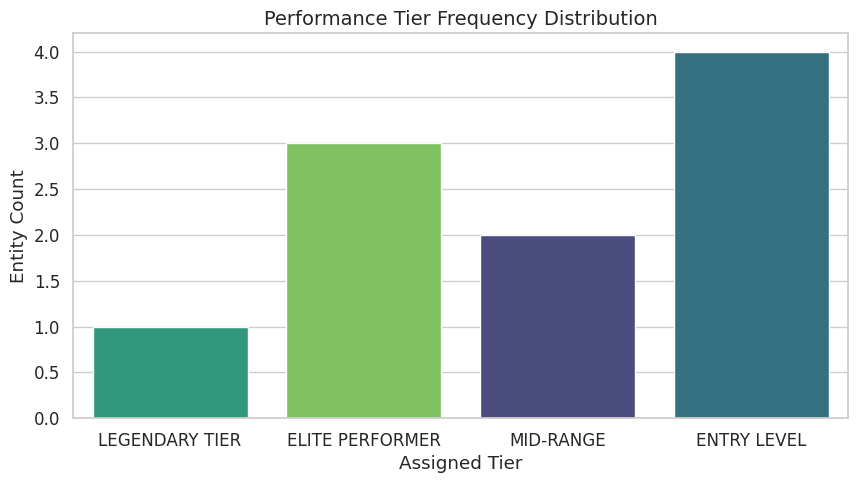

In [36]:
# ==========================================
# SEGMENTATION LOGIC & FEATURE ENGINEERING
# ==========================================

def assign_performance_tier(row):
    """
    Calculates composite score and assigns a categorical tier.
    Criteria: (Attack + Speed) weight and Legendary status.
    """
    composite_score = row['attack'] + row['speed']

    if row['is_legendary']:
        return 'LEGENDARY TIER'
    elif composite_score > 180:
        return 'ELITE PERFORMER'
    elif composite_score > 120:
        return 'MID-RANGE'
    else:
        return 'ENTRY LEVEL'

# Mapping classification logic across the observations
df['performance_tier'] = df.apply(assign_performance_tier, axis=1)

# Summary statistics for generated segments
print("--- SEGMENTATION SUMMARY ---")
print(df['performance_tier'].value_counts())

# Distribution analysis of performance tiers
plt.figure(figsize=(10, 5))
order_list = ['LEGENDARY TIER', 'ELITE PERFORMER', 'MID-RANGE', 'ENTRY LEVEL']
sns.countplot(x='performance_tier', data=df, order=order_list, palette='viridis', hue='performance_tier', legend=False)

plt.title('Performance Tier Frequency Distribution', fontsize=14)
plt.xlabel('Assigned Tier')
plt.ylabel('Entity Count')
plt.show()

--- EXECUTING CASE STUDY 1: RETAIL ---
STATUS: Data integrity verified. Imputation used: 165.0 EUR



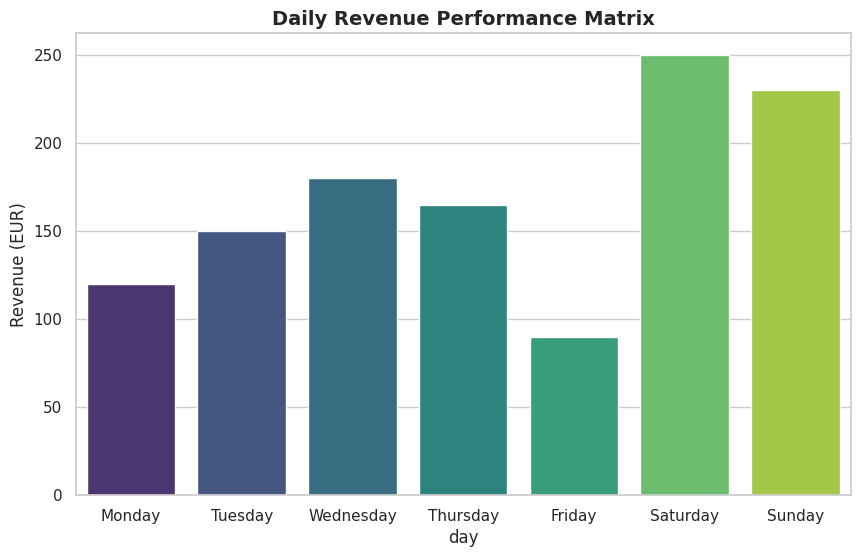


--- EXECUTING CASE STUDY 2: ATTRIBUTES ---


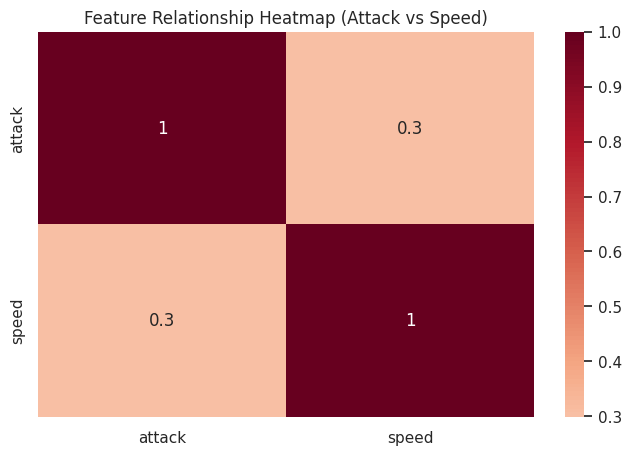

TOP 5 PERFORMERS BY TIER:
        name performance_tier  attack
6  Dragonite  ELITE PERFORMER     134
4     Mewtwo   LEGENDARY TIER     110
7    Snorlax         STANDARD     110
9    Lucario  ELITE PERFORMER     110
5     Gengar         STANDARD      65

✅ PROCESS COMPLETE: Final report exported to 'Portfolio_Final_Report.xlsx'


In [41]:
# ==============================================================================
# DATA ANALYSIS PORTFOLIO: RETAIL PERFORMANCE & CHARACTER SEGMENTATION
# Author: [Your Name]
# Technologies: Python (Pandas, Seaborn, Matplotlib, NumPy)
# ==============================================================================

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Global styling for professional visuals
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# ------------------------------------------------------------------------------
# CASE STUDY 1: RETAIL REVENUE ANALYSIS (CAFE DATA)
# ------------------------------------------------------------------------------
print("--- EXECUTING CASE STUDY 1: RETAIL ---")

# Data Ingestion
retail_raw = {
    'day': ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'],
    'product': ['Espresso', 'Cappuccino', 'Latte', 'Espresso', 'Pastry', 'Cappuccino', 'Latte'],
    'revenue_eur': [120.0, 150.0, 180.0, 110.0, 90.0, 250.0, 230.0]
}
df_sales = pd.DataFrame(retail_raw)

# Data Integrity: Simulated missing record handling
df_sales.loc[3, 'revenue_eur'] = np.nan

# ERROR FIX: Explicit type conversion to ensure numeric operations succeed
df_sales['revenue_eur'] = pd.to_numeric(df_sales['revenue_eur'], errors='coerce')
median_val = df_sales['revenue_eur'].median()
df_sales['revenue_eur'] = df_sales['revenue_eur'].fillna(median_val)

print(f"STATUS: Data integrity verified. Imputation used: {median_val} EUR\n")

# Visualization: Daily Revenue
plt.figure()
sns.barplot(x='day', y='revenue_eur', data=df_sales, palette='viridis', hue='day', legend=False)
plt.title('Daily Revenue Performance Matrix', fontsize=14, fontweight='bold')
plt.ylabel('Revenue (EUR)')
plt.show()

# ------------------------------------------------------------------------------
# CASE STUDY 2: ATTRIBUTE SEGMENTATION (POKEMON DATA)
# ------------------------------------------------------------------------------
print("\n--- EXECUTING CASE STUDY 2: ATTRIBUTES ---")

# Data Initialization
character_raw = {
    'name': ['Pikachu', 'Bulbasaur', 'Charmander', 'Squirtle', 'Mewtwo', 'Gengar', 'Dragonite', 'Snorlax', 'Eevee', 'Lucario'],
    'type_1': ['Electric', 'Grass', 'Fire', 'Water', 'Psychic', 'Ghost', 'Dragon', 'Normal', 'Normal', 'Fighting'],
    'attack': [55, 49, 52, 48, 110, 65, 134, 110, 55, 110],
    'speed': [90, 45, 65, 43, 130, 110, 80, 30, 55, 90],
    'is_legendary': [False, False, False, False, True, False, False, False, False, False]
}
df_pkmn = pd.DataFrame(character_raw)

# Feature Engineering: Classification Algorithm
def assign_tier(row):
    composite_score = row['attack'] + row['speed']
    if row['is_legendary']: return 'LEGENDARY TIER'
    if composite_score > 180: return 'ELITE PERFORMER'
    return 'STANDARD'

df_pkmn['performance_tier'] = df_pkmn.apply(assign_tier, axis=1)

# Multivariate Analysis: Correlation Heatmap
plt.figure(figsize=(8, 5))
numeric_only = df_pkmn.select_dtypes(include=[np.number])
sns.heatmap(numeric_only.corr(), annot=True, cmap='RdBu_r', center=0)
plt.title('Feature Relationship Heatmap (Attack vs Speed)', fontsize=12)
plt.show()

print("TOP 5 PERFORMERS BY TIER:")
print(df_pkmn[['name', 'performance_tier', 'attack']].sort_values(by='attack', ascending=False).head())

# Exporting final results to Excel for stakeholder review
df_pkmn.to_excel('Portfolio_Final_Report.xlsx', index=False)
print("\n✅ PROCESS COMPLETE: Final report exported to 'Portfolio_Final_Report.xlsx'")